# Fiber signature & Rayleigh statistics

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh, expon

from pyofdr.core.config import load_config
from pyofdr.core.acquisition import Acquisition
from pyofdr.fiber.profile import FiberGenerator
from pyofdr.utils.units import dB_to_linear

## Generate the fibre
We just run the `FiberGenerator` step on a fresh `Acquisition`. The default 10 m fibre at the basic config's spatial resolution ($dz \approx 20\,\mu m$) gives ~500k Rayleigh bins, plenty for the
histograms (relative error on the sample mean goes as $1/\sqrt{N}$, so ~0.1 % here).

In [25]:
cfg = load_config('../configs/ofdr_basic.yaml')
acq = FiberGenerator(cfg).process(Acquisition())

profile = acq.fiber_profile[0] # single core
mag, phase, power = np.abs(profile), np.angle(profile), np.abs(profile)**2

R_lin     = dB_to_linear(cfg['fiber']['rayleigh_coefficient_dB'])
dz        = acq.dz
s_theory  = np.sqrt(R_lin * dz / 2.0) # Rayleigh scale (amplitude)
m_theory  = R_lin * dz # exponential mean (power)

s_meas    = rayleigh.fit(mag, floc=0)[1]
m_meas    = float(np.mean(power))

print(f"R_lin = {R_lin:.3e}    (= {cfg['fiber']['rayleigh_coefficient_dB']} dB)")
print(f"dz  = {dz*1e6:.2f} um,    n_z = {len(profile):,}")

print(f"Rayleigh scale (amplitude):")
print(f"theory = {s_theory:.4e}")
print(f"measured = {s_meas:.4e}")

print(f"Exponential mean (|E|^2):")
print(f"theory = {m_theory:.4e}")
print(f"measured = {m_meas:.4e}")

R_lin = 6.310e-09    (= -82.0 dB)
dz  = 20.45 um,    n_z = 488,891
Rayleigh scale (amplitude):
theory = 2.5403e-07
measured = 2.5389e-07
Exponential mean (|E|^2):
theory = 1.2906e-13
measured = 1.2892e-13


## Fiber signature
A linear `|E(z)|` plot. Every bin is an independent random scatterer.
Run the next cell with a different `seed` in the config to see a differen fibre fingerprint.

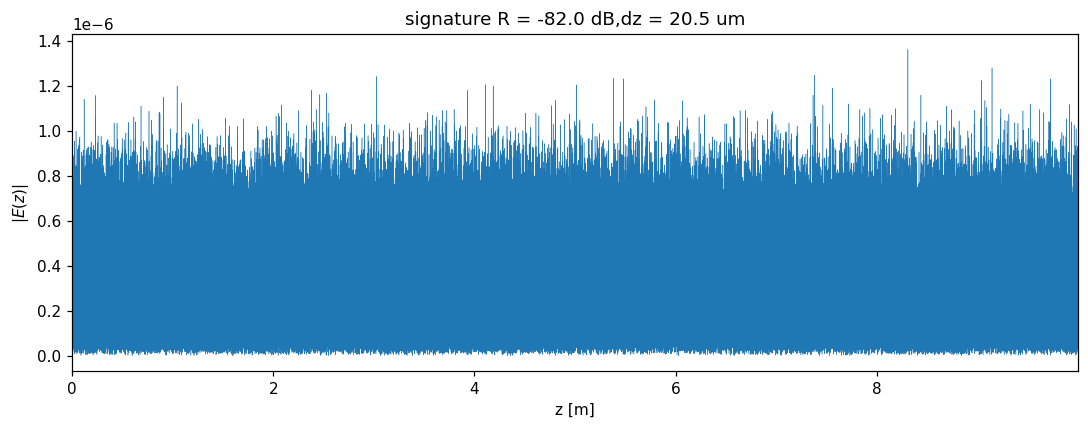

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(acq.z, mag, lw=0.3, color='C0')
ax.set_xlabel('z [m]')
ax.set_ylabel(r'$|E(z)|$')
ax.set_title(f"signature R = {cfg['fiber']['rayleigh_coefficient_dB']} dB," f"dz = {dz*1e6:.1f} um")
ax.set_xlim(0, acq.z[-1])
fig.tight_layout()
plt.show()

## Statistics
The red curves are theoretical (no fitting), only the parameters $R_{\text{lin}}$ and $dz$ from the config feed them.

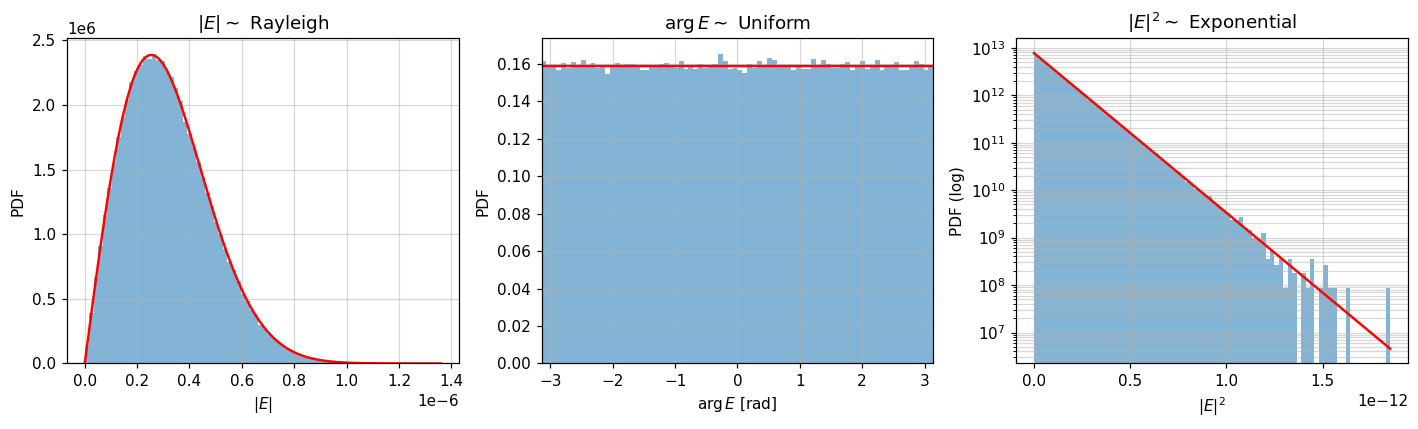

In [34]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(13, 4))

# |E|: Rayleigh
xs = np.linspace(0, mag.max(), 400)
ax1.hist(mag, bins=80, density=True, alpha=0.55)
ax1.plot(xs, rayleigh.pdf(xs, scale=s_theory), 'r-', lw=1.6, label=f'Rayleigh, s = {s_theory:.2e}')
ax1.set_xlabel(r'$|E|$')
ax1.set_ylabel('PDF')
ax1.set_title(r'$|E| \sim$ Rayleigh')
ax1.grid(alpha=0.5)

# arg E: Uniform
ax2.hist(phase, bins=80, density=True, alpha=0.55)
ax2.axhline(1.0/(2*np.pi), color='r', lw=1.6, label=r'$1/(2\pi)$')
ax2.set_xlabel(r'$\arg E$ [rad]')
ax2.set_ylabel('PDF')
ax2.set_title(r'$\arg E \sim$ Uniform')
ax2.set_xlim(-np.pi, np.pi)
ax2.grid(alpha=0.5)

# |E|^2: Exponential
xs2 = np.linspace(power.min(), power.max(), 400)
ax3.hist(power, bins=80, density=True, alpha=0.55)
ax3.plot(xs2, expon.pdf(xs2, scale=m_theory), 'r-', lw=1.6, label=f'Expon, mean = {m_theory:.2e}')
ax3.set_xlabel(r'$|E|^2$')
ax3.set_ylabel('PDF (log)')
ax3.set_title(r'$|E|^2 \sim$ Exponential')
ax3.set_yscale('log')
ax3.grid(alpha=0.5, which='both')

fig.tight_layout()
plt.show()